# SuppFig — SBS5 accumulation with age, and SBS1/SBS5 vs SBS3

- **Panel a.** Scaled SBS5 exposure (`SBS5_total / (G · 3000)`, WGD-corrected) vs age across
  INFORM, SCANB, PCAWG plus normal breast tissue with a linear fit; dashed lines mark
  diploid-genome SBS5 counts (800/1600/2400/3200 → value/6000).
- **Panel b.** Per-patient bootstrap (`n = 200`) exposures: SBS3 vs SBS5 and SBS3 vs SBS1
  scatter, with violins of the per-patient Spearman ρ across cohorts.

Inputs are cached in `data/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3/` and summarised in `SupTable3_SBS5_age_and_SBS1_SBS5_vs_SBS3.xlsx`.

In [1]:
# --- Nature figure style: 0.25 lw spines/ticks, no top/right spines ---
import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.size": 9,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

def nature_axes(ax, keep_top=False):
    """Apply Nature spine/tick styling to a single Axes."""
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

COLORS = {"INFORM": "#DFCC94", "SCANB": "#93A55D", "PCAWG": "#0F4722"}

panelA    = pd.read_csv("data/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3/panelA_SBS5_vs_age.csv")
normal    = pd.read_csv("data/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3/panelA_normal_tissue_SBS5.csv")
bootstrap = pd.read_csv("data/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3/panelB_bootstrap_exposures.csv")
spearman  = pd.read_csv("data/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3/panelB_spearman_per_patient.csv")

OUT = "../output/SuppFig_SBS5_age_SBS1_SBS5_vs_SBS3"
os.makedirs(OUT, exist_ok=True)
print("panel A:", panelA.shape, "| normal:", normal.shape,
      "| bootstrap:", bootstrap.shape, "| spearman:", spearman.shape)
panelA.head()

panel A: (156, 7) | normal: (32, 5) | bootstrap: (18200, 6) | spearman: (182, 6)


,sample,Cohort,age,G,SBS5_total,scaled_SBS5,HRDetect.isHRD
0,01658141-8398-4585-9f0f-8355dd9b0604,PCAWG,62.0,2.440164,2761.030704,0.377165,False
1,110b5f05-ded7-45ec-b0f6-a941c92d77dd,PCAWG,41.0,2.090937,984.946446,0.157018,True
2,13c312ec-0add-4758-ab8d-c193e2e08c6d,PCAWG,71.0,2.187724,1336.710583,0.203668,False
3,1c0e384f-7254-4afe-93c0-b3fc6c6a7894,PCAWG,66.0,3.540255,5903.824820,0.555876,False
4,1eb62abc-7928-405b-84cc-f091ca5347b2,PCAWG,61.0,2.619774,3232.548213,0.411301,False


## Panel a — scaled SBS5 vs age


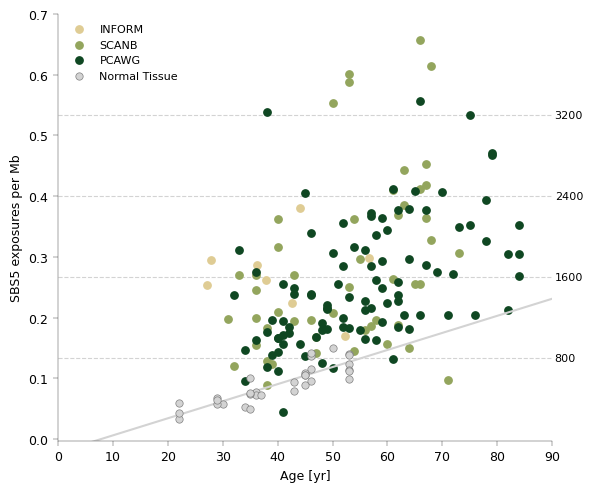

In [3]:
slope, intercept, *_ = linregress(normal["age"], normal["scaled_SBS5"])
x_fit = np.linspace(0, 90, 100)

fig, ax = plt.subplots(figsize=(6, 5))
for cohort, color in COLORS.items():
    d = panelA[panelA["Cohort"] == cohort]
    ax.scatter(d["age"], d["scaled_SBS5"], label=cohort, color=color, s=28)
ax.scatter(normal["age"], normal["scaled_SBS5"], color="lightgrey", label="Normal Tissue",
           edgecolors="grey", linewidths=0.5, s=28, zorder=10)
ax.plot(x_fit, slope * x_fit + intercept, "-", color="lightgrey")

for val in [800, 1600, 2400, 3200]:
    y = val / 6000
    ax.axhline(y=y, linestyle="--", color="lightgrey", linewidth=0.8, zorder=0)
    ax.text(90.5, y, f"{val}", va="center", ha="left", fontsize=8)

ax.set_xlabel("Age [yr]"); ax.set_ylabel("SBS5 exposures per Mb")
ax.set_xlim(0, 90); ax.set_ylim(-0.003, 0.7)
ax.margins(x=0.12)                       # room for the right-hand value labels
ax.legend(loc="upper left", frameon=False, fontsize=8)
nature_axes(ax)
fig.tight_layout()
fig.savefig(f"{OUT}/panel_a_SBS5_vs_age.pdf", bbox_inches="tight")
plt.show()

## Panel b — SBS1 / SBS5 vs SBS3 (bootstrap scatter + per-patient Spearman ρ)


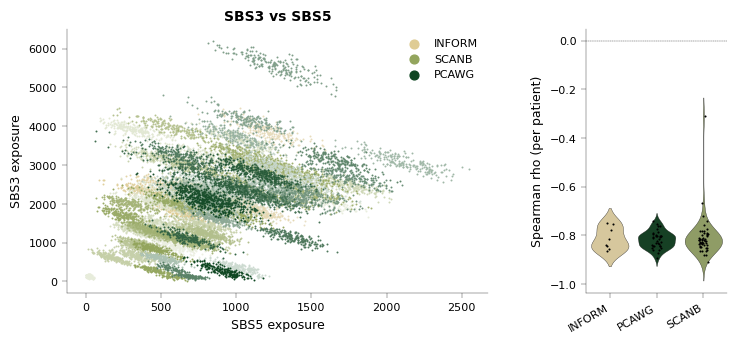

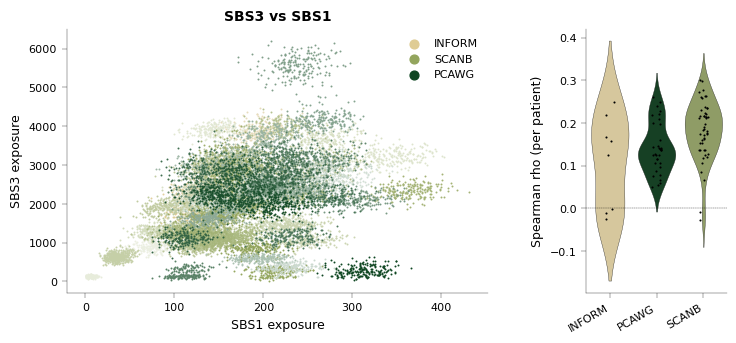

In [4]:
def plot_corr(x_sig, y_sig, boot, spear, colors=COLORS):
    filt = boot[(boot[x_sig] != 0) & (boot[y_sig] != 0)].copy()
    corr = spear[spear["comparison"] == f"{x_sig}_vs_{y_sig}"]

    sample_colors = {}
    for cohort, base in colors.items():
        samples = filt[filt["cohort"] == cohort]["sample"].unique()
        pal = sns.light_palette(base, n_colors=len(samples) + 2)[2:]
        sample_colors.update(dict(zip(samples, pal)))

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7.5, 4),
                                   gridspec_kw={"width_ratios": [3, 1], "wspace": 0.35})
    for cohort in colors:
        for sample, g in filt[filt["cohort"] == cohort].groupby("sample"):
            ax0.scatter(g[x_sig], g[y_sig], color=sample_colors[sample], s=2, linewidths=0)
        ax0.scatter([], [], color=colors[cohort], label=cohort, s=10)
    ax0.set_xlabel(f"{x_sig} exposure", fontsize=9)
    ax0.set_ylabel(f"{y_sig} exposure", fontsize=9)
    ax0.set_title(f"{y_sig} vs {x_sig}", fontsize=10, fontweight="bold")
    ax0.legend(markerscale=2, fontsize=8, frameon=False); ax0.tick_params(labelsize=8)

    order = ["INFORM", "PCAWG", "SCANB"]
    # Assign hue=cohort (+ legend=False) so `palette` is used without the seaborn warning.
    sns.violinplot(data=corr, x="cohort", y="rho", order=order, hue="cohort",
                   hue_order=order, palette=colors, legend=False,
                   inner=None, linewidth=0.25, ax=ax1)
    sns.stripplot(data=corr, x="cohort", y="rho", order=order, color="black",
                  size=1.5, jitter=True, ax=ax1)
    ax1.axhline(0, color="black", lw=0.25, ls="--")
    ax1.set_xlabel(""); ax1.set_ylabel("Spearman rho (per patient)", fontsize=9)
    ax1.tick_params(axis="x", rotation=30, labelsize=8); ax1.tick_params(axis="y", labelsize=8)
    for lbl in ax1.get_xticklabels():
        lbl.set_ha("right")
    nature_axes(ax0); nature_axes(ax1)
    # Reserve spacing here (constrained-layout compatible) instead of tight_layout.
    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.22, top=0.88, wspace=0.35)
    fig.savefig(f"{OUT}/panel_b_{y_sig}_vs_{x_sig}.pdf", bbox_inches="tight")
    plt.show()

plot_corr("SBS5", "SBS3", bootstrap, spearman)
plot_corr("SBS1", "SBS3", bootstrap, spearman)